# Import Library

In [1]:
%pip install psycopg2 sqlalchemy
%pip install pandas as pd
%pip install numpy as np
%pip install matplotlib.pyplot as plt
%pip install seaborn as sns

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


In [2]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()

connection = psycopg2.connect(
    host=os.environ.get("DB_HOST", "localhost"),
    database=os.environ.get("DB_NAME", "airbnb"),
    user=os.environ.get("DB_USER", "postgres"),
    password=os.environ.get("DB_PASSWORD"),
    port=os.environ.get("DB_PORT", "5432"),
)

In [4]:
query = """
SELECT table_name 
FROM information_schema.tables 
WHERE table_schema = 'public'
"""
tables_df = pd.read_sql_query(query, connection)
print(tables_df)

                 table_name
0        airbnb_kab_bandung
1  airbnb_kab_bandung_barat
2        airbnb_kota_cimahi
3    airbnb_bandungraya_all
4       airbnb_kota_bandung


C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_19708\1048451943.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables_df = pd.read_sql_query(query, connection)


In [5]:
query = "SELECT * FROM airbnb_bandungraya_all"
df = pd.read_sql_query(query, connection)

df

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_19708\2179646782.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,nama,harga,rating,jumlah_review,link,wilayah
0,Home in Cibeunying Kaler - Serene Pet-Friendly...,"Rp 9,848,899",5.0,33,https://www.airbnb.com/rooms/1647712818622104523,Kota Bandung
1,"Apartment in Cidadap - Dago, Ciumbuleuit, ITB ...","Rp 3,446,781",4.98,132,https://www.airbnb.com/rooms/1583745571091269827,Kota Bandung
2,Home in Sukajadi - Pine Breeze W/ Backyard,"Rp 12,500,000",4.95,112,https://www.airbnb.com/rooms/1400529902543354123,Kota Bandung
3,Apartment in Cidadap - Abony | Bandung | PVJ |...,"Rp 2,054,119",4.87,38,https://www.airbnb.com/rooms/1496783488914922824,Kota Bandung
4,Home in Cidadap - Wangiterrace,"Rp 9,883,877",4.98,51,https://www.airbnb.com/rooms/1504314537783385401,Kota Bandung
...,...,...,...,...,...,...
567,Home in Kecamatan Sukajadi - Spacious 4BR Vill...,"Rp 9,892,233",4.87,15,https://www.airbnb.com/rooms/1385448894932972520,Kabupaten Bandung Barat
568,Guest suite in Kecamatan Sukajadi - Beautiful ...,"Rp 7,555,672",4.96,83,https://www.airbnb.com/rooms/1043230693114228999,Kabupaten Bandung Barat
569,Villa in Parompong - Montrii House - Alvar Sui...,"Rp 16,054,260",4.97,35,https://www.airbnb.com/rooms/562498271762366418,Kabupaten Bandung Barat
570,"Villa in Bandung - ""Cipaku Rumah Villa""","Rp 14,721,183",4.95,329,https://www.airbnb.com/rooms/17773568,Kabupaten Bandung Barat


In [52]:
pd.set_option('display.max_colwidth', None)

# Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   nama           572 non-null    object
 1   harga          572 non-null    object
 2   rating         572 non-null    object
 3   jumlah_review  572 non-null    int64 
 4   link           572 non-null    object
 5   wilayah        572 non-null    object
dtypes: int64(1), object(5)
memory usage: 26.9+ KB


In [7]:
df.isnull().sum()

nama             0
harga            0
rating           0
jumlah_review    0
link             0
wilayah          0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df['harga'] = df['harga'].str.replace('Rp', '', case=False).str.strip()

df['harga'] = df['harga'].str.replace(',', '')

df['harga'] = df['harga'].astype(float)

df

,nama,harga,rating,jumlah_review,link,wilayah
0,Home in Cibeunying Kaler - Serene Pet-Friendly...,9848899.0,5.0,33,https://www.airbnb.com/rooms/1647712818622104523,Kota Bandung
1,"Apartment in Cidadap - Dago, Ciumbuleuit, ITB ...",3446781.0,4.98,132,https://www.airbnb.com/rooms/1583745571091269827,Kota Bandung
2,Home in Sukajadi - Pine Breeze W/ Backyard,12500000.0,4.95,112,https://www.airbnb.com/rooms/1400529902543354123,Kota Bandung
3,Apartment in Cidadap - Abony | Bandung | PVJ |...,2054119.0,4.87,38,https://www.airbnb.com/rooms/1496783488914922824,Kota Bandung
4,Home in Cidadap - Wangiterrace,9883877.0,4.98,51,https://www.airbnb.com/rooms/1504314537783385401,Kota Bandung
...,...,...,...,...,...,...
567,Home in Kecamatan Sukajadi - Spacious 4BR Vill...,9892233.0,4.87,15,https://www.airbnb.com/rooms/1385448894932972520,Kabupaten Bandung Barat
568,Guest suite in Kecamatan Sukajadi - Beautiful ...,7555672.0,4.96,83,https://www.airbnb.com/rooms/1043230693114228999,Kabupaten Bandung Barat
569,Villa in Parompong - Montrii House - Alvar Sui...,16054260.0,4.97,35,https://www.airbnb.com/rooms/562498271762366418,Kabupaten Bandung Barat
570,"Villa in Bandung - ""Cipaku Rumah Villa""",14721183.0,4.95,329,https://www.airbnb.com/rooms/17773568,Kabupaten Bandung Barat


In [10]:
df['rating'].unique()

array(['5.0', '4.98', '4.95', '4.87', '4.8', '4.96', 'New', '4.99',
       '4.91', '4.93', '4.9', '4.82', '4.78', '4.92', '4.97', '4.94',
       '4.89', '4.81', '4.88', '4.86', '4.85', '4.84', '4.6', '4.39',
       '4.75', '4.83', '4.62', '4.68', 'N/A', '4.64', '4.74', '4.77',
       '4.5', '4.67', '4.71', '4.79', '4.37', '4.7', '4.69', '4.73',
       '4.33', '4.48', '4.72', '4.32', '4.29', '4.76', '4.55'],
      dtype=object)

In [11]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df

,nama,harga,rating,jumlah_review,link,wilayah
0,Home in Cibeunying Kaler - Serene Pet-Friendly...,9848899.0,5.00,33,https://www.airbnb.com/rooms/1647712818622104523,Kota Bandung
1,"Apartment in Cidadap - Dago, Ciumbuleuit, ITB ...",3446781.0,4.98,132,https://www.airbnb.com/rooms/1583745571091269827,Kota Bandung
2,Home in Sukajadi - Pine Breeze W/ Backyard,12500000.0,4.95,112,https://www.airbnb.com/rooms/1400529902543354123,Kota Bandung
3,Apartment in Cidadap - Abony | Bandung | PVJ |...,2054119.0,4.87,38,https://www.airbnb.com/rooms/1496783488914922824,Kota Bandung
4,Home in Cidadap - Wangiterrace,9883877.0,4.98,51,https://www.airbnb.com/rooms/1504314537783385401,Kota Bandung
...,...,...,...,...,...,...
567,Home in Kecamatan Sukajadi - Spacious 4BR Vill...,9892233.0,4.87,15,https://www.airbnb.com/rooms/1385448894932972520,Kabupaten Bandung Barat
568,Guest suite in Kecamatan Sukajadi - Beautiful ...,7555672.0,4.96,83,https://www.airbnb.com/rooms/1043230693114228999,Kabupaten Bandung Barat
569,Villa in Parompong - Montrii House - Alvar Sui...,16054260.0,4.97,35,https://www.airbnb.com/rooms/562498271762366418,Kabupaten Bandung Barat
570,"Villa in Bandung - ""Cipaku Rumah Villa""",14721183.0,4.95,329,https://www.airbnb.com/rooms/17773568,Kabupaten Bandung Barat


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   nama           572 non-null    object 
 1   harga          572 non-null    float64
 2   rating         520 non-null    float64
 3   jumlah_review  572 non-null    int64  
 4   link           572 non-null    object 
 5   wilayah        572 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 26.9+ KB


In [13]:
df.isnull().sum()

nama              0
harga             0
rating           52
jumlah_review     0
link              0
wilayah           0
dtype: int64

In [14]:
df['rating'].unique()

array([5.  , 4.98, 4.95, 4.87, 4.8 , 4.96,  nan, 4.99, 4.91, 4.93, 4.9 ,
       4.82, 4.78, 4.92, 4.97, 4.94, 4.89, 4.81, 4.88, 4.86, 4.85, 4.84,
       4.6 , 4.39, 4.75, 4.83, 4.62, 4.68, 4.64, 4.74, 4.77, 4.5 , 4.67,
       4.71, 4.79, 4.37, 4.7 , 4.69, 4.73, 4.33, 4.48, 4.72, 4.32, 4.29,
       4.76, 4.55])

In [15]:
df['rating'] = df['rating'].fillna(0)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   nama           572 non-null    object 
 1   harga          572 non-null    float64
 2   rating         572 non-null    float64
 3   jumlah_review  572 non-null    int64  
 4   link           572 non-null    object 
 5   wilayah        572 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 26.9+ KB


# Explanatory Data Analysis

1. Distribusi harga per wilayah (Kota Bandung vs Kabupaten Bandung Barat, dll) — boxplot/histogram
2. Hubungan antara rating dan jumlah_review — apakah listing dengan review lebih banyak cenderung rating lebih tinggi/stabil?
3. Wilayah mana yang punya harga rata-rata tertinggi/terendah?
4. Deteksi outlier harga (ada listing yang harganya jauh di atas/bawah rata-rata?)

In [17]:
import matplotlib.ticker as ticker

In [18]:
df['harga'].describe().apply(lambda x: f'{x:,.2f}')

count           572.00
mean     10,429,418.95
std      10,485,050.55
min         925,000.00
25%       4,072,045.00
50%       7,554,086.00
75%      12,002,709.00
max      94,000,000.00
Name: harga, dtype: object

In [19]:
df[df['harga'] <= 10000000]['harga'].describe().apply(lambda x: f'{x:,.2f}')

count           375.00
mean      5,437,470.62
std       2,510,065.74
min         925,000.00
25%       3,071,459.50
50%       5,477,650.00
75%       7,506,768.00
max      10,000,000.00
Name: harga, dtype: object

In [20]:
df[df['harga'] > 10000000]['harga'].describe().apply(lambda x: f'{x:,.2f}')

count           197.00
mean     19,931,858.66
std      13,031,368.04
min      10,042,358.00
25%      11,820,596.00
50%      14,721,183.00
75%      22,780,350.00
max      94,000,000.00
Name: harga, dtype: object

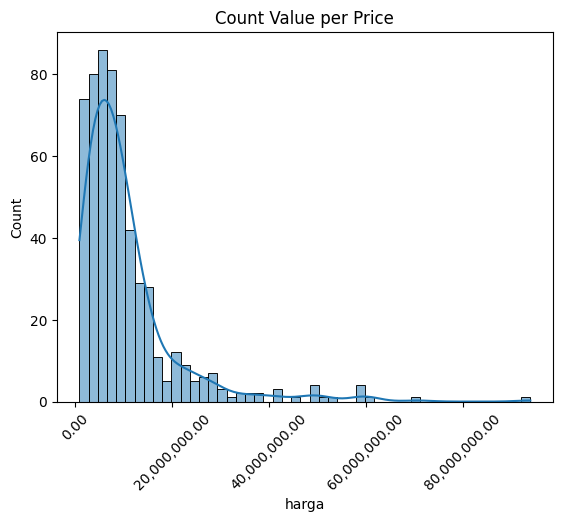

In [21]:
fig, axes = plt.subplots()
sns.histplot(df, x='harga', kde=True, cbar=True, ax=axes)
axes.set_title('Count Value per Price')
axes.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.2f}'))
plt.xticks(rotation=45)
plt.show()

In [22]:
print(f'{round(df[df['harga'] <= 10000000]['harga'].count() * 100 / df['harga'].count(), 2)}%')
print('='*7)
print(f'{round(df[df['harga'] > 10000000]['harga'].count() * 100 / df['harga'].count(), 2)}%')

65.56%
34.44%


**Description**:

Dari cell di atas, dapat disimpulkan bahwa penginapan di bandung dibawah 10 juta rupiah mendominasi sektor layanan dengan nilai 65.56% dari semua data penginapan yang tersimpan. 

In [23]:
df['rating'].describe()

count    572.000000
mean       4.453287
std        1.413633
min        0.000000
25%        4.820000
50%        4.910000
75%        4.980000
max        5.000000
Name: rating, dtype: float64

In [24]:
bins = [0, 3, 4, 4.5, 4.7, 4.9, 5]
labels = ['0-3', '3-4', '4-4.5', '4.5-4.7', '4.7-4.9', '4.9-5']

df['rating_bin'] = pd.cut(df['rating'], bins=bins, labels=labels, include_lowest=True)

In [25]:
df.groupby('rating_bin')['harga'].describe().style.format('{:,.2f}')

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_19708\2857071040.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rating_bin')['harga'].describe().style.format('{:,.2f}')


,count,mean,std,min,25%,50%,75%,max
rating_bin,,,,,,,,
0-3,52.00,"16,161,465.40","15,119,543.58","925,000.00","6,368,673.00","10,975,000.00","22,950,862.50","59,750,000.00"
3-4,0.00,nan,nan,nan,nan,nan,nan,nan
4-4.5,9.00,"8,914,275.00","1,566,311.82","7,189,415.00","7,303,533.00","9,129,416.00","10,200,000.00","11,411,770.00"
4.5-4.7,23.00,"8,845,653.09","5,137,623.38","1,035,000.00","5,809,286.50","8,501,769.00","10,644,203.50","26,500,000.00"
4.7-4.9,187.00,"8,277,338.03","5,842,966.21","1,412,207.00","3,850,736.00","7,303,533.00","10,162,762.00","38,115,312.00"
4.9-5,301.00,"10,942,494.12","11,751,933.05","1,000,000.00","3,765,452.00","7,417,651.00","12,512,476.00","94,000,000.00"


In [26]:
df.groupby('rating_bin')['jumlah_review'].describe()

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_19708\736358256.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rating_bin')['jumlah_review'].describe()


,count,mean,std,min,25%,50%,75%,max
rating_bin,,,,,,,,
0-3,52.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
3-4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4-4.5,9.0,33.888889,47.627315,3.0,7.0,19.0,27.0,155.0
4.5-4.7,23.0,64.347826,70.991426,3.0,15.5,44.0,84.0,241.0
4.7-4.9,187.0,93.818182,107.513936,4.0,26.5,58.0,123.0,822.0
4.9-5,301.0,59.222591,77.108497,3.0,12.0,31.0,73.0,456.0


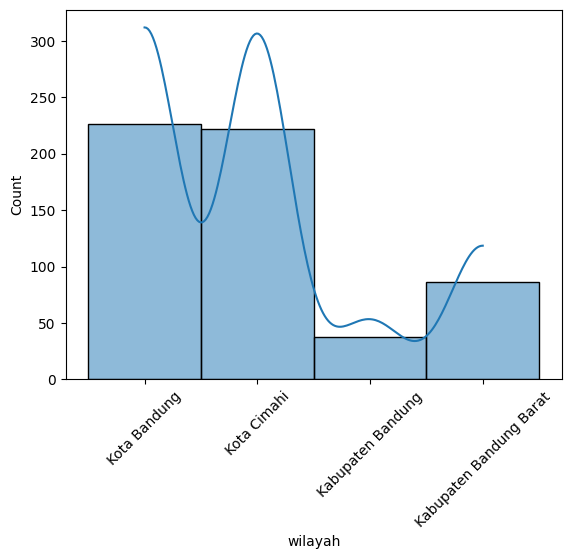

In [27]:
sns.histplot(df, x='wilayah', kde=True)
plt.xticks(rotation=45)
plt.show()

In [28]:
df['wilayah'].value_counts()

wilayah
Kota Bandung               226
Kota Cimahi                222
Kabupaten Bandung Barat     86
Kabupaten Bandung           38
Name: count, dtype: int64

In [29]:
df['wilayah_coded'] = df['wilayah'].astype('category').cat.codes

df

,nama,harga,rating,jumlah_review,link,wilayah,rating_bin,wilayah_coded
0,Home in Cibeunying Kaler - Serene Pet-Friendly...,9848899.0,5.00,33,https://www.airbnb.com/rooms/1647712818622104523,Kota Bandung,4.9-5,2
1,"Apartment in Cidadap - Dago, Ciumbuleuit, ITB ...",3446781.0,4.98,132,https://www.airbnb.com/rooms/1583745571091269827,Kota Bandung,4.9-5,2
2,Home in Sukajadi - Pine Breeze W/ Backyard,12500000.0,4.95,112,https://www.airbnb.com/rooms/1400529902543354123,Kota Bandung,4.9-5,2
3,Apartment in Cidadap - Abony | Bandung | PVJ |...,2054119.0,4.87,38,https://www.airbnb.com/rooms/1496783488914922824,Kota Bandung,4.7-4.9,2
4,Home in Cidadap - Wangiterrace,9883877.0,4.98,51,https://www.airbnb.com/rooms/1504314537783385401,Kota Bandung,4.9-5,2
...,...,...,...,...,...,...,...,...
567,Home in Kecamatan Sukajadi - Spacious 4BR Vill...,9892233.0,4.87,15,https://www.airbnb.com/rooms/1385448894932972520,Kabupaten Bandung Barat,4.7-4.9,1
568,Guest suite in Kecamatan Sukajadi - Beautiful ...,7555672.0,4.96,83,https://www.airbnb.com/rooms/1043230693114228999,Kabupaten Bandung Barat,4.9-5,1
569,Villa in Parompong - Montrii House - Alvar Sui...,16054260.0,4.97,35,https://www.airbnb.com/rooms/562498271762366418,Kabupaten Bandung Barat,4.9-5,1
570,"Villa in Bandung - ""Cipaku Rumah Villa""",14721183.0,4.95,329,https://www.airbnb.com/rooms/17773568,Kabupaten Bandung Barat,4.9-5,1


In [30]:
df['wilayah_coded'].value_counts()

wilayah_coded
2    226
3    222
1     86
0     38
Name: count, dtype: int64

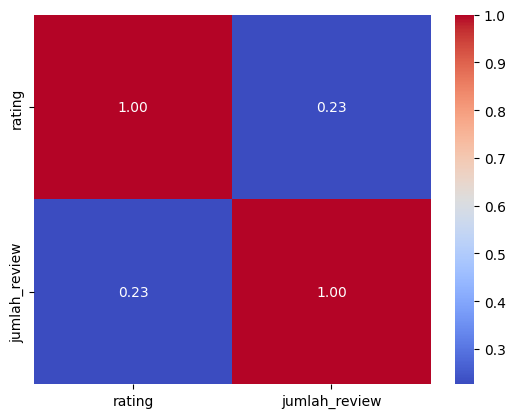

In [31]:
corHeat = df[['rating', 'jumlah_review']].corr()

sns.heatmap(corHeat, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

Description : 

Hubungan antara rating dan jumlah review adalah **Lemah Positif**, yang mengindikasikan kedua variabel memiliki hubungan yang tidak erat. Ini menunjukan bahwa jumlah review tidak mempengaruhi rating dari suatu penginapan.

In [32]:
df.groupby('wilayah')['harga'].describe().style.format('{:,.2f}')

,count,mean,std,min,25%,50%,75%,max
wilayah,,,,,,,,
Kabupaten Bandung,38.00,"6,610,667.13","4,259,941.28","1,460,707.00","3,576,245.00","5,589,997.50","8,112,654.50","22,780,350.00"
Kabupaten Bandung Barat,86.00,"11,910,811.10","9,895,653.91","1,412,207.00","6,285,238.50","8,454,495.00","14,746,933.50","61,623,558.00"
Kota Bandung,226.00,"6,868,040.48","8,238,995.03","1,000,000.00","2,782,082.75","4,849,501.00","8,067,677.75","70,752,974.00"
Kota Cimahi,222.00,"14,134,753.98","12,004,547.49","925,000.00","7,546,147.25","10,263,175.50","15,181,648.50","94,000,000.00"


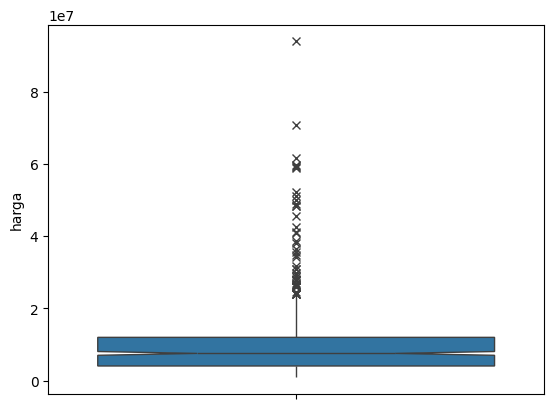

In [33]:
fig, axes = plt.subplots()
sns.boxplot(df['harga'], flierprops={"marker" : "x"}, notch=True, showcaps=False)
plt.xticks(rotation=45)
plt.show()

In [38]:
df.groupby('wilayah')['harga'].mean().sort_values(ascending=False).apply(lambda x: f'{x:,.0f}')

wilayah
Kota Cimahi                14,134,754
Kabupaten Bandung Barat    11,910,811
Kota Bandung                6,868,040
Kabupaten Bandung           6,610,667
Name: harga, dtype: object

In [40]:
df = df.drop(columns='link')

df

,nama,harga,rating,jumlah_review,wilayah,rating_bin,wilayah_coded
0,Home in Cibeunying Kaler - Serene Pet-Friendly...,9848899.0,5.00,33,Kota Bandung,4.9-5,2
1,"Apartment in Cidadap - Dago, Ciumbuleuit, ITB ...",3446781.0,4.98,132,Kota Bandung,4.9-5,2
2,Home in Sukajadi - Pine Breeze W/ Backyard,12500000.0,4.95,112,Kota Bandung,4.9-5,2
3,Apartment in Cidadap - Abony | Bandung | PVJ |...,2054119.0,4.87,38,Kota Bandung,4.7-4.9,2
4,Home in Cidadap - Wangiterrace,9883877.0,4.98,51,Kota Bandung,4.9-5,2
...,...,...,...,...,...,...,...
567,Home in Kecamatan Sukajadi - Spacious 4BR Vill...,9892233.0,4.87,15,Kabupaten Bandung Barat,4.7-4.9,1
568,Guest suite in Kecamatan Sukajadi - Beautiful ...,7555672.0,4.96,83,Kabupaten Bandung Barat,4.9-5,1
569,Villa in Parompong - Montrii House - Alvar Sui...,16054260.0,4.97,35,Kabupaten Bandung Barat,4.9-5,1
570,"Villa in Bandung - ""Cipaku Rumah Villa""",14721183.0,4.95,329,Kabupaten Bandung Barat,4.9-5,1


In [54]:
df

,nama,harga,rating,jumlah_review,wilayah,rating_bin,wilayah_coded
0,"Home in Cibeunying Kaler - Serene Pet-Friendly Family Lux Villa, Aqua Ville",9848899.0,5.00,33,Kota Bandung,4.9-5,2
1,"Apartment in Cidadap - Dago, Ciumbuleuit, ITB | Cozy & Comfort | 4 Guests",3446781.0,4.98,132,Kota Bandung,4.9-5,2
2,Home in Sukajadi - Pine Breeze W/ Backyard,12500000.0,4.95,112,Kota Bandung,4.9-5,2
3,Apartment in Cidadap - Abony | Bandung | PVJ | Lembang | Pool,2054119.0,4.87,38,Kota Bandung,4.7-4.9,2
4,Home in Cidadap - Wangiterrace,9883877.0,4.98,51,Kota Bandung,4.9-5,2
...,...,...,...,...,...,...,...
567,"Home in Kecamatan Sukajadi - Spacious 4BR Villa ParisVanJava, Pasteur, Paskal",9892233.0,4.87,15,Kabupaten Bandung Barat,4.7-4.9,1
568,Guest suite in Kecamatan Sukajadi - Beautiful Living Garden Pasteur,7555672.0,4.96,83,Kabupaten Bandung Barat,4.9-5,1
569,Villa in Parompong - Montrii House - Alvar Suite- Mid Century Villa,16054260.0,4.97,35,Kabupaten Bandung Barat,4.9-5,1
570,"Villa in Bandung - ""Cipaku Rumah Villa""",14721183.0,4.95,329,Kabupaten Bandung Barat,4.9-5,1


In [55]:
df['tipe'] = df['nama'].str.extract(r'^([\w\s]+?)\s+in\s')

df

,nama,harga,rating,jumlah_review,wilayah,rating_bin,wilayah_coded,tipe
0,"Home in Cibeunying Kaler - Serene Pet-Friendly Family Lux Villa, Aqua Ville",9848899.0,5.00,33,Kota Bandung,4.9-5,2,Home
1,"Apartment in Cidadap - Dago, Ciumbuleuit, ITB | Cozy & Comfort | 4 Guests",3446781.0,4.98,132,Kota Bandung,4.9-5,2,Apartment
2,Home in Sukajadi - Pine Breeze W/ Backyard,12500000.0,4.95,112,Kota Bandung,4.9-5,2,Home
3,Apartment in Cidadap - Abony | Bandung | PVJ | Lembang | Pool,2054119.0,4.87,38,Kota Bandung,4.7-4.9,2,Apartment
4,Home in Cidadap - Wangiterrace,9883877.0,4.98,51,Kota Bandung,4.9-5,2,Home
...,...,...,...,...,...,...,...,...
567,"Home in Kecamatan Sukajadi - Spacious 4BR Villa ParisVanJava, Pasteur, Paskal",9892233.0,4.87,15,Kabupaten Bandung Barat,4.7-4.9,1,Home
568,Guest suite in Kecamatan Sukajadi - Beautiful Living Garden Pasteur,7555672.0,4.96,83,Kabupaten Bandung Barat,4.9-5,1,Guest suite
569,Villa in Parompong - Montrii House - Alvar Suite- Mid Century Villa,16054260.0,4.97,35,Kabupaten Bandung Barat,4.9-5,1,Villa
570,"Villa in Bandung - ""Cipaku Rumah Villa""",14721183.0,4.95,329,Kabupaten Bandung Barat,4.9-5,1,Villa


In [56]:
df['tipe'].unique()

array(['Home', 'Apartment', 'Villa', 'Tiny home', 'Condo', 'Room',
       'Guesthouse', 'Boutique hotel', 'Guest suite', 'Rooms', 'Cabin',
       'Bungalow', 'Place to stay', 'Earthen home', 'Farm stay',
       'Cottage', 'Tent', 'Treehouse', 'Townhouse', 'Hotel',
       'Shared room', 'Nature lodge'], dtype=object)